In [1]:
pip install pandas openpyxl scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_excel("Dataset_for_Data_Analytics.xlsx")  # your actual DecodeLabs file

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Shape: (1200, 14)

Missing values:
CouponCode    309
dtype: int64


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
print(df["CouponCode"].value_counts(dropna=False))

CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64


In [5]:
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")
df["has_coupon"] = (df["CouponCode"] != "NoCoupon").astype(int)

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


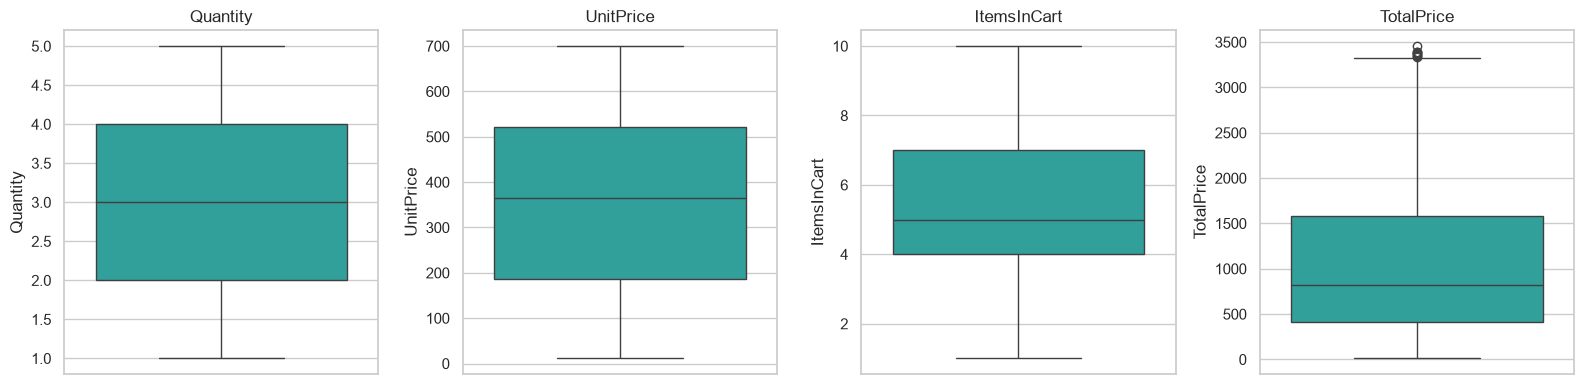

Quantity: bounds=(-1.00, 7.00), outliers=0
UnitPrice: bounds=(-317.20, 1024.83), outliers=0
ItemsInCart: bounds=(-0.50, 11.50), outliers=0
TotalPrice: bounds=(-1341.41, 3330.41), outliers=8


In [6]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

numeric_check = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

fig, axes = plt.subplots(1, len(numeric_check), figsize=(4 * len(numeric_check), 4))
for ax, col in zip(axes, numeric_check):
    sns.boxplot(y=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in numeric_check:
    lower, upper = iqr_bounds(df[col])
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: bounds=({lower:.2f}, {upper:.2f}), outliers={n_outliers}")

In [7]:
for col in numeric_check:
    lower, upper = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped. Row count unchanged:", len(df))

Outliers capped. Row count unchanged: 1200


In [8]:
df["order_month"] = df["Date"].dt.month
df["order_dayofweek"] = df["Date"].dt.dayofweek
df["cart_fill_ratio"] = df["Quantity"] / df["ItemsInCart"]
df["customer_order_count"] = df.groupby("CustomerID")["OrderID"].transform("count")

df[["Date", "order_month", "order_dayofweek", "Quantity", "ItemsInCart",
    "cart_fill_ratio", "CustomerID", "customer_order_count"]].head()

,Date,order_month,order_dayofweek,Quantity,ItemsInCart,cart_fill_ratio,CustomerID,customer_order_count
0,2023-01-04,1,2,5,7,0.714286,C72649,1
1,2024-08-23,8,4,2,3,0.666667,C75739,1
2,2024-02-27,2,1,5,8,0.625000,C81728,1
3,2023-10-15,10,6,1,5,0.200000,C33540,1
4,2025-05-08,5,3,4,8,0.500000,C81840,1


In [9]:
df_encoded = pd.get_dummies(df, columns=["Product", "PaymentMethod", "OrderStatus", "ReferralSource"], drop_first=True)
print(f"Final shape: {df_encoded.shape}")
df_encoded.head()

Final shape: (1200, 33)


,OrderID,Date,CustomerID,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,TotalPrice,has_coupon,order_month,order_dayofweek,cart_fill_ratio,customer_order_count,Product_Desk,Product_Laptop,Product_Monitor,Product_Phone,Product_Printer,Product_Tablet,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,ORD200000,2023-01-04,C72649,5,570.62,928 Main St,TRK37947903,7,SAVE10,2853.10,1,1,2,0.714286,1,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
1,ORD200001,2024-08-23,C75739,2,151.35,823 Main St,TRK91186779,3,SAVE10,302.70,1,8,4,0.666667,1,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True
2,ORD200002,2024-02-27,C81728,5,550.68,512 Main St,TRK42903982,8,FREESHIP,2753.40,1,2,1,0.625000,1,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False
3,ORD200003,2023-10-15,C33540,1,273.19,275 Main St,TRK62788070,5,SAVE10,273.19,1,10,6,0.200000,1,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False
4,ORD200004,2025-05-08,C81840,4,626.01,668 Main St,TRK29241424,8,SAVE10,2504.04,1,5,3,0.500000,1,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False


In [10]:
df_encoded = pd.get_dummies(df, columns=["Product", "PaymentMethod", "OrderStatus", "ReferralSource"], drop_first=True)
print(f"Final shape: {df_encoded.shape}")
df_encoded.head()

Final shape: (1200, 33)


,OrderID,Date,CustomerID,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,TotalPrice,has_coupon,order_month,order_dayofweek,cart_fill_ratio,customer_order_count,Product_Desk,Product_Laptop,Product_Monitor,Product_Phone,Product_Printer,Product_Tablet,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,ORD200000,2023-01-04,C72649,5,570.62,928 Main St,TRK37947903,7,SAVE10,2853.10,1,1,2,0.714286,1,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
1,ORD200001,2024-08-23,C75739,2,151.35,823 Main St,TRK91186779,3,SAVE10,302.70,1,8,4,0.666667,1,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True
2,ORD200002,2024-02-27,C81728,5,550.68,512 Main St,TRK42903982,8,FREESHIP,2753.40,1,2,1,0.625000,1,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False
3,ORD200003,2023-10-15,C33540,1,273.19,275 Main St,TRK62788070,5,SAVE10,273.19,1,10,6,0.200000,1,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False
4,ORD200004,2025-05-08,C81840,4,626.01,668 Main St,TRK29241424,8,SAVE10,2504.04,1,5,3,0.500000,1,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False
